In [1]:
from __future__ import division, print_function, absolute_import

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
import utilities as util

import os
import importlib

from tensorflow import keras
from tensorflow.keras import layers
from scipy import signal
from nptdms import TdmsFile
from tkinter import filedialog

import generate_lorentz as gl
import generate_data as gd
import classify_data as cd
import efficient_data_generation as ed
import data_spy as ds
import sliding_window as sw
import train_model as tm

importlib.reload(cd)
importlib.reload(ed)
importlib.reload(ds)
importlib.reload(gl)
importlib.reload(sw)
importlib.reload(tm)
importlib.reload(util)

<module 'utilities' from '/home/gabriel/Seconcephalon/Projects/LEPRECHAUN/Analytis Laboratory/ML Peak Tracker/utilities.py'>

In [2]:
F = np.linspace(0,1,2 ** 10)
plt.rcParams['figure.figsize'] = 50, 5

[[0. 1. 0. 1. 0.]]


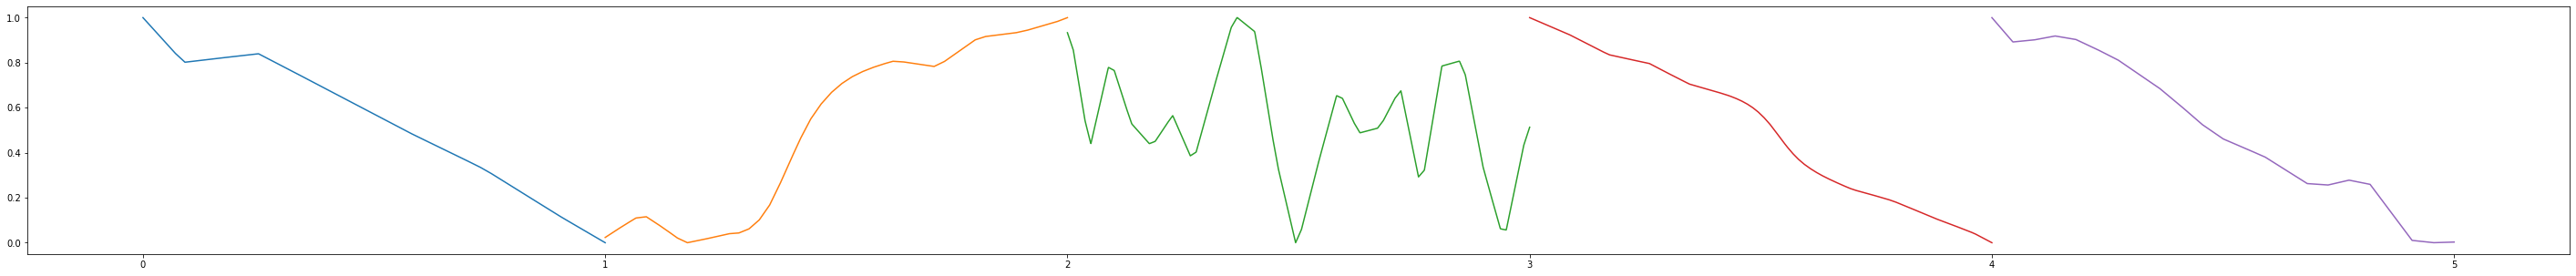

In [3]:
(label, data) = ed.make_single_data_set(5, noise=True, min_noise_amp=0.01, max_noise_amp=5, min_noise_width=1, max_noise_width=10, expansion=1, wiggle=2, scale=(0,1,1024))
print(np.transpose(label))
for i in range(0, len(label)):
    plt.plot(F + i, data[i])

In [4]:
# Make new testing data
sing_test = ed.make_single_data_set(1000)

Generating Data: [########################################] 1000/1000

In [7]:
# Load existing model
sing_model = keras.models.load_model(os.path.join(os.getcwd(), 'models',  'tight_wiggle'))
# count_model = keras.models.load_model(os.path.join(os.getcwd(), 'models', 'class_hidden_layer_1024'))

In [8]:
sing_loss, sing_acc = sing_model.evaluate(sing_test[1], sing_test[0])

32/32 [==============================] - 0s 1ms/step - loss: 0.3298 - accuracy: 0.9880


In [9]:
tdms_f, tdms_v = util.import_file()

/home/gabriel/.local/lib/python3.8/site-packages/nptdms/tdms.py:1068: UserWarning: 'TdmsFile.object' is deprecated and will be removed in a future release. Use TdmsFile.properties to access properties of the root object, TdmsFile[group_name] to access a group object and TdmsFile[group_name][channel_name] to access a channel object.
  warnings.warn(message)
/home/gabriel/.local/lib/python3.8/site-packages/nptdms/tdms.py:1068: UserWarning: 'TdmsFile.objects' is deprecated and will be removed in a future release. Use TdmsFile.groups() to access all groups in the file, and group.channels() to access all channels in a group.
  warnings.warn(message)


In [16]:
importlib.reload(sw)
reduce_zoom = 1
regions = sw.slide_scale(sing_model, tdms_v, num_zooms=8, confidence_tolerance=0.95, min_zoom=7)

[[ 977. 1396. 1582. 1670. 2100. 2188. 2295. 2441. 2529. 2588. 2773. 2949.
  3008. 3115. 3213. 3398. 3486. 3721. 3906. 3994. 4775.]
 [1055. 1484. 1655. 1719. 2139. 2227. 2334. 2480. 2568. 2627. 2842. 2988.
  3047. 3154. 3252. 3438. 3525. 3760. 3945. 4033. 4810.]]


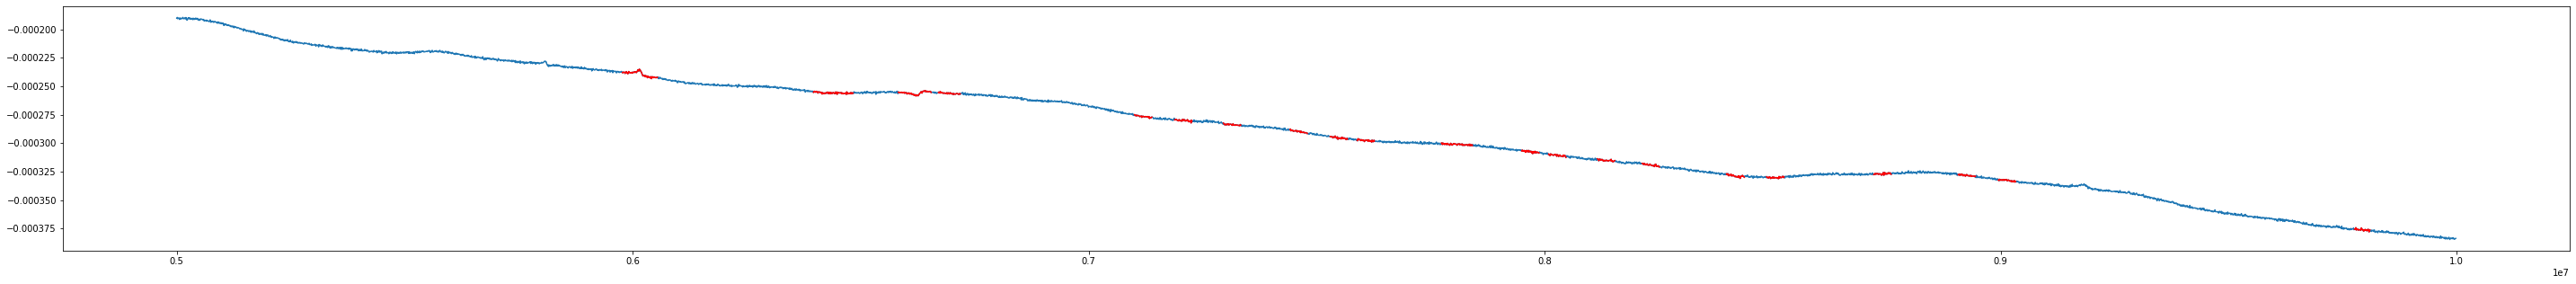

In [17]:
importlib.reload(util)

plt.plot(tdms_f, tdms_v)
print(np.transpose(regions))
for j in range(0, len(regions)):
    util.plot_region(j, regions, tdms_f, tdms_v, color='r', show_boundaries=False, min_color='g', max_color='y')